## speed tests

### TODO:
- compare relative speedup to 2-core size
- compare relative speedup of fns to that of omidi g-tries, see if it outperforms it
- try cython

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import functions_regular as fnr
import functions_subtrees as fns
import functions_regular_wc as fnr_wc
import functions_subtrees_wc as fns_wc
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import itertools as it
import collections
import math
import time
import pickle
import json
importlib.reload(fnr)
importlib.reload(fns)
importlib.reload(fnr_wc)
importlib.reload(fns_wc)

<module 'functions_subtrees_wc' from '/Users/mbpr/Desktop/internships/CU Boulder Summer 2019/Motif discovery/motif-discovery/src/functions_subtrees_wc.py'>

# measure relative speedup on sample of real networks

# ColiNet-1.1

### read and clean up

In [86]:
# convert file format to string  
    
file = "test_data/ColiNet-1.1/coliInterFullVec.txt"
stringGraph = edgeList_to_string(file)
Graph = parseStringToGraph(stringGraph)

stringQuery = '[[0,1],[0,2],[0,3],[3,4],[3,5]]'
Query = parseStringToGraph(stringQuery)


In [87]:
# choose only largest connected component

largest_cc = max(nx.connected_components(Graph), key=len)
x = list(largest_cc)[0]
F = nx.Graph()

for r in largest_cc:

    F.add_node(r)

    for i in largest_cc:
        for j in largest_cc:
            if ((i, j) in Graph.edges()):
                F.add_edge(i, j)
                    
Graph = nx.Graph()
Graph.add_edges_from(F.edges())

In [88]:
# remove self loops
Graph.remove_edges_from(Graph.selfloop_edges())

# reorder labels from 0 to Graph size - 1
F = nx.Graph()
F = fnr.relabelByDegree(Graph)

Graph = nx.Graph()
Graph.add_edges_from(F.edges())
stringGraph = graphToString(Graph)

list(sorted(Graph.nodes()))

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


### plot

In [ ]:
pos = nx.drawing.kamada_kawai_layout(Graph, scale=1)

fig, ax = plt.subplots()
fig.set_size_inches(18, 18)


nodes = nx.draw_networkx_nodes(Graph, pos=pos, node_size = 0, ax = ax)
edges = nx.draw_networkx_edges(Graph, pos=pos, ax = ax)
labels = nx.draw_networkx_labels(Graph, pos=pos)

plt.show()

### compare speed

In [91]:
start_time_fns = time.time()
out_fns = fns.findSubgraphInstances(stringQuery, stringGraph)
delta_fns = time.time() - start_time_fns

start_time_fnr = time.time()
out_fnr = fnr.findSubgraphInstances(Query, Graph)
delta_fnr = time.time() - start_time_fnr  

print(stringQuery)
print('subtrees:', delta_fns), 'regular:', delta_fnr)

[[0,1],[0,2],[0,3],[3,4],[3,5]]
subtrees: 308.6806831359863


In [83]:
outFile = 'test_data/speed_tests/colinet_1_ryser.txt'

write_speed_results(outFile, delta_fnr, delta_fns, stringQuery, 'colinet1.1')

# CommunityFitNet_updated

### read

In [2]:
f = open('test_data/CommunityFitNet_updated.pickle', 'rb')
data = pickle.load(f)

In [3]:
data_edgelists = data['edges_id']
data.columns

Index(['network_index', 'network_name', 'title', 'description',
       'networkDomain', 'subDomain', 'citation', 'sourceUrl', 'hostedBy',
       'graphProperties', 'nodeType', 'edgeType', 'nodes_id', 'edges_id',
       'number_nodes', 'number_edges', 'ave_degree', 'labels_Q', 'labels_Q_MR',
       'labels_Q_MP', 'labels_Q_GMP', 'labels_B_NR_SBM', 'labels_B_NR_DCSBM',
       'labels_B_HKK_SBM', 'labels_cICL_HKK_SBM', 'labels_Infomap',
       'labels_MDL_SBM', 'labels_MDL_DCSBM', 'labels_S_NB', 'labels_S_cBHm',
       'labels_S_cBHa', 'labels_AMOS', 'labels_AMOS_reliablity',
       'labels_LRT_WB_DCSBM', 'Q_score', 'Q_MR_score', 'Q_MP_score',
       'Q_GMP_score', 'B_NR_SBM_score', 'B_NR_DCSBM_score', 'B_HKK_SBM_score',
       'cICL_HKK_SBM_score', 'Infomap_score', 'MDL_SBM_score',
       'MDL_DCSBM_score', 'S_NB_score', 'S_cBHm_score', 'S_cBHa_score',
       'AMOS_score', 'LRT_WB_DCSBM_score'],
      dtype='object')

### browse networks

In [16]:
from operator import itemgetter, attrgetter

networks = [(data['network_index'][i], 
              data['number_nodes'][i],
              data['title'][i]) for i in range(len(data)) if data['graphProperties'][i][0] == 'U']

# sored by size
sorted(networks, key = itemgetter(1))


[(9, 5, 'Binary interactomes (various species; 2012)'),
 (10, 5, 'Binary interactomes (various species; 2012)'),
 (12, 8, 'Binary interactomes (various species; 2012)'),
 (45, 9, 'Davidson plant-ant web'),
 (13, 13, 'Binary interactomes (various species; 2012)'),
 (416, 15, 'AMiner citation network (2009)'),
 (417, 15, 'AMiner citation network (2009)'),
 (128, 18, 'Malaria var DBLa HVR networks'),
 (421, 19, 'AMiner citation network (2009)'),
 (23, 22, 'Binary interactomes (various species; 2012)'),
 (24, 22, 'Binary interactomes (various species; 2012)'),
 (138, 22, 'Mosquin & Martin plant-pollinator web'),
 (365, 22, 'Olesen plant-pollinator web'),
 (394, 23, 'Vazquez & Simberloff plant-pollinator webs'),
 (373, 24, 'Poulin seed-disperser web'),
 (14, 26, 'Binary interactomes (various species; 2012)'),
 (366, 27, 'Olesen plant-pollinator web'),
 (28, 28, 'Binary interactomes (various species; 2012)'),
 (380, 28, 'Smallwood Reservoir host-parasite web'),
 (52, 29, 'Fonseca & Ganade pl

### view details

In [41]:
data['sourceUrl'][375]

'http://www.ncbi.nlm.nih.gov/pmc/articles/PMC1561585/'

### plot a network

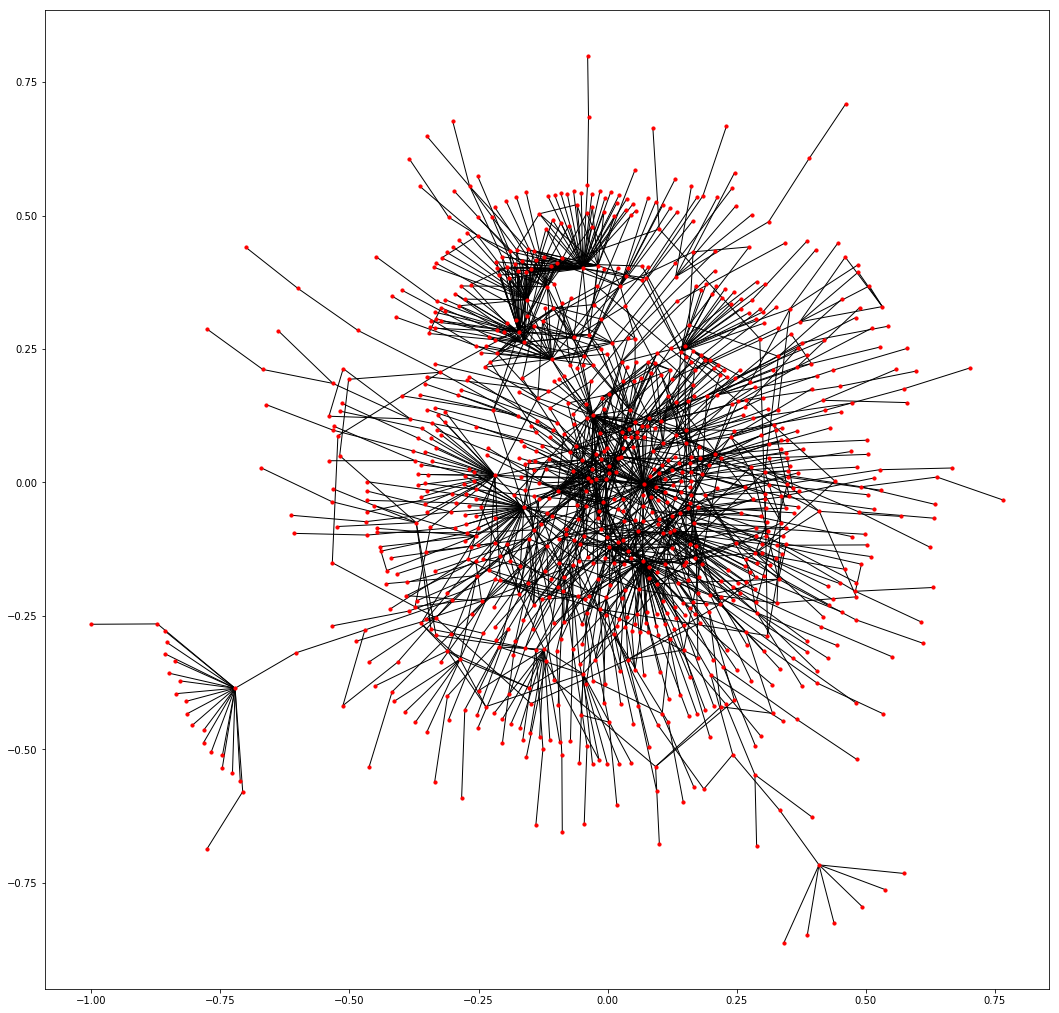

In [350]:
#arguments: networkIndex, nodeSize, withLabels, figSize
plotNetwork(402, 10, False, 18)

In [353]:
networkGraph = nx.Graph()
edges = data_edgelists.iloc[375]
networkGraph.add_edges_from(edges)

fns.onionDecompose(networkGraph)

maxBushLength = 0

for node in networkGraph:
    if (networkGraph.nodes[node]['is_root']):
        
        neighborhood = networkGraph[node]
        bushLength = len([i for i in neighborhood if networkGraph.nodes[i]['coreness'] == 1])
        
        if (bushLength > maxBushLength):
            maxBushLength = bushLength
            
            
maxBushLength

19

### plot query graph

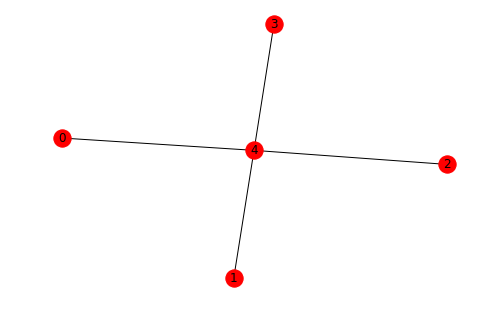

In [15]:
queryString = '[[0,4], [1,4], [2,4], [3,4]]'
queryGraph = parseStringToGraph(queryString)
nx.draw(queryGraph, with_labels=True)

### test early abort by coreness

In [68]:
networkIndex = 372

# without early abort by coreness
networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)

queryString = '[[0,1], [0,2], [0,3], [0,4], [0,5], [0,6], [0,7], [1,2], [1,3], [1,4], [1,5], [1,6], [1,7], [2,3], [2,4], [2,5], [2,6], [2,7], [3,4], [3,5], [3,6], [3,7], [4,5], [4,6], [4,7], [5,6], [5,7], [6,7]]'
queryGraph = parseStringToGraph(queryString)

start_time_fnr = time.time()
out_fnr = fnr_wc.findSubgraphInstances(queryGraph, networkGraph, True)
delta_fnr = time.time() - start_time_fnr


# with early abort by coreness
networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)
fns.onionDecompose(networkGraph)

queryGraph = parseStringToGraph(queryString)
fns.onionDecompose(queryGraph)

start_time_fnr_wc = time.time()
out_fnr_wc = fnr_wc.findSubgraphInstances(queryGraph, networkGraph, True)
delta_fnr_wc = time.time() - start_time_fnr_wc

print(delta_fnr, delta_fnr_wc)


114.36780405044556 99.60093402862549


In [ ]:
print(out_fnr, out_fnr_wc)
queryGraph.nodes[0]['coreness']

### view k-core spectrum

In [62]:
networkGraph = nx.Graph()
edges = data_edgelists.iloc[372]
networkGraph.add_edges_from(edges)
traversal = fns.onionDecompose(networkGraph)

print([(traversal[i], networkGraph.nodes[traversal[i]]['coreness']) for i in range(len(networkGraph))])

oneShellSize = len([networkGraph.nodes[i]['coreness'] for i in networkGraph.nodes() if networkGraph.nodes[i]['coreness']==1])

print('1-shell size',oneShellSize)
print('2-core size',len(networkGraph)-oneShellSize)
print('network size', len(networkGraph))

[(103, 2), (104, 2), (16, 3), (18, 3), (28, 3), (50, 3), (92, 3), (1, 4), (2, 4), (15, 4), (29, 4), (46, 4), (48, 4), (55, 4), (56, 4), (67, 4), (80, 4), (68, 4), (69, 4), (81, 4), (102, 4), (95, 4), (61, 4), (63, 4), (0, 4), (19, 4), (43, 4), (57, 4), (65, 4), (101, 4), (59, 4), (4, 4), (5, 4), (85, 4), (51, 4), (94, 4), (60, 4), (62, 4), (52, 4), (64, 4), (6, 5), (7, 5), (17, 5), (21, 5), (25, 5), (58, 5), (32, 5), (42, 5), (44, 5), (36, 5), (53, 5), (93, 5), (78, 5), (34, 5), (88, 5), (90, 5), (96, 5), (97, 5), (87, 5), (98, 5), (22, 5), (49, 5), (77, 5), (70, 5), (89, 5), (13, 6), (14, 6), (20, 6), (35, 6), (37, 6), (45, 6), (38, 6), (39, 6), (54, 6), (99, 6), (91, 6), (10, 6), (23, 6), (26, 6), (31, 6), (33, 6), (41, 6), (100, 6), (3, 6), (11, 6), (24, 6), (27, 6), (40, 6), (47, 6), (79, 6), (83, 6), (86, 6), (8, 6), (9, 6), (12, 6), (71, 6), (66, 6), (30, 6), (72, 6), (73, 6), (74, 6), (76, 6), (75, 6), (82, 6), (84, 6)]
1-shell size 0
2-core size 105
network size 105


### find all undirected networks in dataset

In [ ]:
undirected_networks = ''

for i in list(data['network_index']):
    if (data['graphProperties'][i][0] == 'U'):
        undirected_networks += str(i) + ' '
        
undirected_networks

### compare runtimes on a selection of networks

In [503]:
# network data, selections
data_edgelists = data['edges_id']
indices_smallSelection = [513, 372, 254, 33, 471, 4, 464, 503]

querySize = 5

inputFile = 'test_data/allgraphs' + str(querySize) + 'indexed.txt'
f = open(inputFile, 'r')
queryGraphsData = f.readlines()

results = {}

for networkKey, networkIndex in enumerate(indices_smallSelection):
    
    # create nx.graph and string encoding of network
    networkGraph = nx.Graph()
    edges = data_edgelists.iloc[networkIndex]
    networkGraph.add_edges_from(edges)
    networkString = graphToString(networkGraph)
    
    runtimes = {}
    sig = False

    # get test motifs
    for key, val in enumerate(queryGraphsData):
        
        spaceIndex = val.find(' ')
        queryKey = val[:spaceIndex]
        queryString = val[spaceIndex+1:].rstrip()
        queryGraph = parseStringToGraph(queryString)
        networkGraph = parseStringToGraph(networkString)
        
        print('network:', networkIndex, 'query:', queryString)
        
        # run fnr, fns
        start_time_fns = time.time()
        out_fns = fns_wc.findSubgraphInstances(queryString, networkString)
        delta_fns = time.time() - start_time_fns
        
        start_time_fnr = time.time()
        out_fnr = fnr_wc.findSubgraphInstances(queryGraph, networkGraph, True)
        delta_fnr = time.time() - start_time_fnr
        
        if (out_fnr != out_fns):
            sig = True
            print('error! outputs unequal at query', queryString, 'and network', networkIndex)
            break
        
        # store index, delta, queryGraph, 2-core size in dict
        runtimes[queryKey] = {'runtime_fnr': delta_fnr,
                              'runtime_fns': delta_fns}
        
        currentStep = (networkKey)*len(queryGraphsData) + key
        totalSteps = len(indices_smallSelection) * len(queryGraphsData)
        
        print('progress: ', int(currentStep*100/totalSteps), '%')
        
    if (sig):
        break
    
    results[networkIndex] = runtimes

print(results)

network: 513 query: [[0,2], [1,3], [2,4], [3,4]]
progress:  0 %
network: 513 query: [[0,1], [0,2], [1,3], [2,4], [3,4]]
progress:  0 %
network: 513 query: [[0,3], [1,4], [2,4], [3,4]]
progress:  1 %
network: 513 query: [[0,4], [1,2], [1,3], [2,4], [3,4]]
progress:  1 %
network: 513 query: [[0,3], [0,4], [1,3], [1,4], [2,3], [2,4]]
progress:  2 %
network: 513 query: [[0,4], [1,4], [2,4], [3,4]]
progress:  2 %
network: 513 query: [[0,1], [1,4], [2,3], [2,4], [3,4]]
progress:  3 %
network: 513 query: [[0,3], [1,4], [2,3], [2,4], [3,4]]
progress:  4 %
network: 513 query: [[0,1], [0,3], [1,4], [2,3], [2,4], [3,4]]
progress:  4 %
network: 513 query: [[0,4], [1,4], [2,3], [2,4], [3,4]]
progress:  5 %
network: 513 query: [[0,1], [0,4], [1,4], [2,3], [2,4], [3,4]]
progress:  5 %
network: 513 query: [[0,2], [1,3], [1,4], [2,3], [2,4], [3,4]]
progress:  6 %
network: 513 query: [[0,1], [0,2], [1,3], [1,4], [2,3], [2,4], [3,4]]
progress:  7 %
network: 513 query: [[0,4], [1,3], [1,4], [2,3], [2,4], 

progress:  61 %
network: 471 query: [[0,1], [0,2], [0,3], [0,4], [1,2], [1,3], [1,4], [2,3], [2,4], [3,4]]
progress:  61 %
network: 4 query: [[0,2], [1,3], [2,4], [3,4]]
progress:  62 %
network: 4 query: [[0,1], [0,2], [1,3], [2,4], [3,4]]
progress:  63 %
network: 4 query: [[0,3], [1,4], [2,4], [3,4]]
progress:  63 %
network: 4 query: [[0,4], [1,2], [1,3], [2,4], [3,4]]
progress:  64 %
network: 4 query: [[0,3], [0,4], [1,3], [1,4], [2,3], [2,4]]
progress:  64 %
network: 4 query: [[0,4], [1,4], [2,4], [3,4]]
progress:  65 %
network: 4 query: [[0,1], [1,4], [2,3], [2,4], [3,4]]
progress:  66 %
network: 4 query: [[0,3], [1,4], [2,3], [2,4], [3,4]]
progress:  66 %
network: 4 query: [[0,1], [0,3], [1,4], [2,3], [2,4], [3,4]]
progress:  67 %
network: 4 query: [[0,4], [1,4], [2,3], [2,4], [3,4]]
progress:  67 %
network: 4 query: [[0,1], [0,4], [1,4], [2,3], [2,4], [3,4]]
progress:  68 %
network: 4 query: [[0,2], [1,3], [1,4], [2,3], [2,4], [3,4]]
progress:  69 %
network: 4 query: [[0,1], [0,2

In [504]:
with open('test_data/speed_tests/small_sample/results_allgraphs5_on_8sample.json', 'w') as fp:
    json.dump(results, fp)

### calculate total runtime

In [505]:
totalTime = 0

for i in indices_smallSelection:
    for j in range(21):
        totalTime = totalTime + results[i][str(j)]['runtime_fnr'] + results[i][str(j)]['runtime_fns']
        
totalTime/60

178.79789437055587

In [18]:
indices_smallSelection = [513, 372, 254, 33, 471, 4, 464, 503]

In [170]:
data = {}
runtimes = {}
obj = {}

for querySize in range(3, 8):
    with open('test_data/speed_tests/8sample/results_allgraphs'+str(querySize)+'_on_8sample.json', 'r') as fp:
        data[querySize] = fp.read()
        obj[querySize] = json.loads(data[querySize])

howManyQuerys = [2, 6, 21, 112, 853]
# print(obj)

for networkIndex in indices_smallSelection:
    runtimes[networkIndex] = {}
    
    for querySize in range(3, 8):
        
        totalRuntime_fnr = 0
        totalRuntime_fns = 0
        
        for i in range(howManyQuerys[querySize-3]):
            if (not (querySize == 6 and networkIndex == 33 and i >= 18 and i <=19) and not (querySize == 7 and (networkIndex == 33 or networkIndex == 4 or networkIndex == 503 or networkIndex == 372))):
                if (obj[querySize][str(networkIndex)][str(i)] != 'error'):
                    totalRuntime_fnr = totalRuntime_fnr + obj[querySize][str(networkIndex)][str(i)]['runtime_fnr']
                    totalRuntime_fns = totalRuntime_fns + obj[querySize][str(networkIndex)][str(i)]['runtime_fns']
        
#         print(networkIndex, querySize, totalRuntime_fnr, totalRuntime_fns)

        runtimes[networkIndex][querySize] = {'total_fnr': totalRuntime_fnr,
                                             'total_fns': totalRuntime_fns}
    
for networkIndex in [33,4,503]:
    
    querySize = 7
    totalRuntime_fns = 0
    
    for i in range(howManyQuerys[querySize-3]):
        if (not (i >= 0 and i <= 2)):
            if (obj[querySize][str(networkIndex)][str(i)] != 'error'):
                totalRuntime_fns = totalRuntime_fns + obj[querySize][str(networkIndex)][str(i)]['runtime_fns']
        
    runtimes[networkIndex][querySize] = {'total_fns': totalRuntime_fns,
                                         'total_fnr': None}
    
runtimes[372][7] = {'total_fns': None,
                    'total_fnr': None}

### plot networks and runtime comparison

In [165]:
runtimes[372][7] = None
runtimes[33][7]

{513: {3: {'total_fnr': 1.2768888473510742, 'total_fns': 4.803285121917725},
  4: {'total_fnr': 7.793758869171143, 'total_fns': 12.92606234550476},
  5: {'total_fnr': 38.47878646850586, 'total_fns': 55.831568002700806},
  6: {'total_fnr': 272.589453458786, 'total_fns': 336.8269901275635},
  7: {'total_fnr': 1905.7834084033966, 'total_fns': 2222.0020327568054}},
 372: {3: {'total_fnr': 3.4057679176330566, 'total_fns': 5.806246995925903},
  4: {'total_fnr': 57.95198607444763, 'total_fns': 67.53426790237427},
  5: {'total_fnr': 790.1029720306396, 'total_fns': 847.0071620941162},
  6: {'total_fnr': 10815.674908638, 'total_fns': 11433.831305742264},
  7: None},
 254: {3: {'total_fnr': 1.3231987953186035, 'total_fns': 0.8321044445037842},
  4: {'total_fnr': 12.6171875, 'total_fns': 2.8492627143859863},
  5: {'total_fnr': 91.22603631019592, 'total_fns': 12.152817726135254},
  6: {'total_fnr': 765.1496515274048, 'total_fns': 89.01155757904053},
  7: {'total_fnr': 6010.840097427368, 'total_fns'

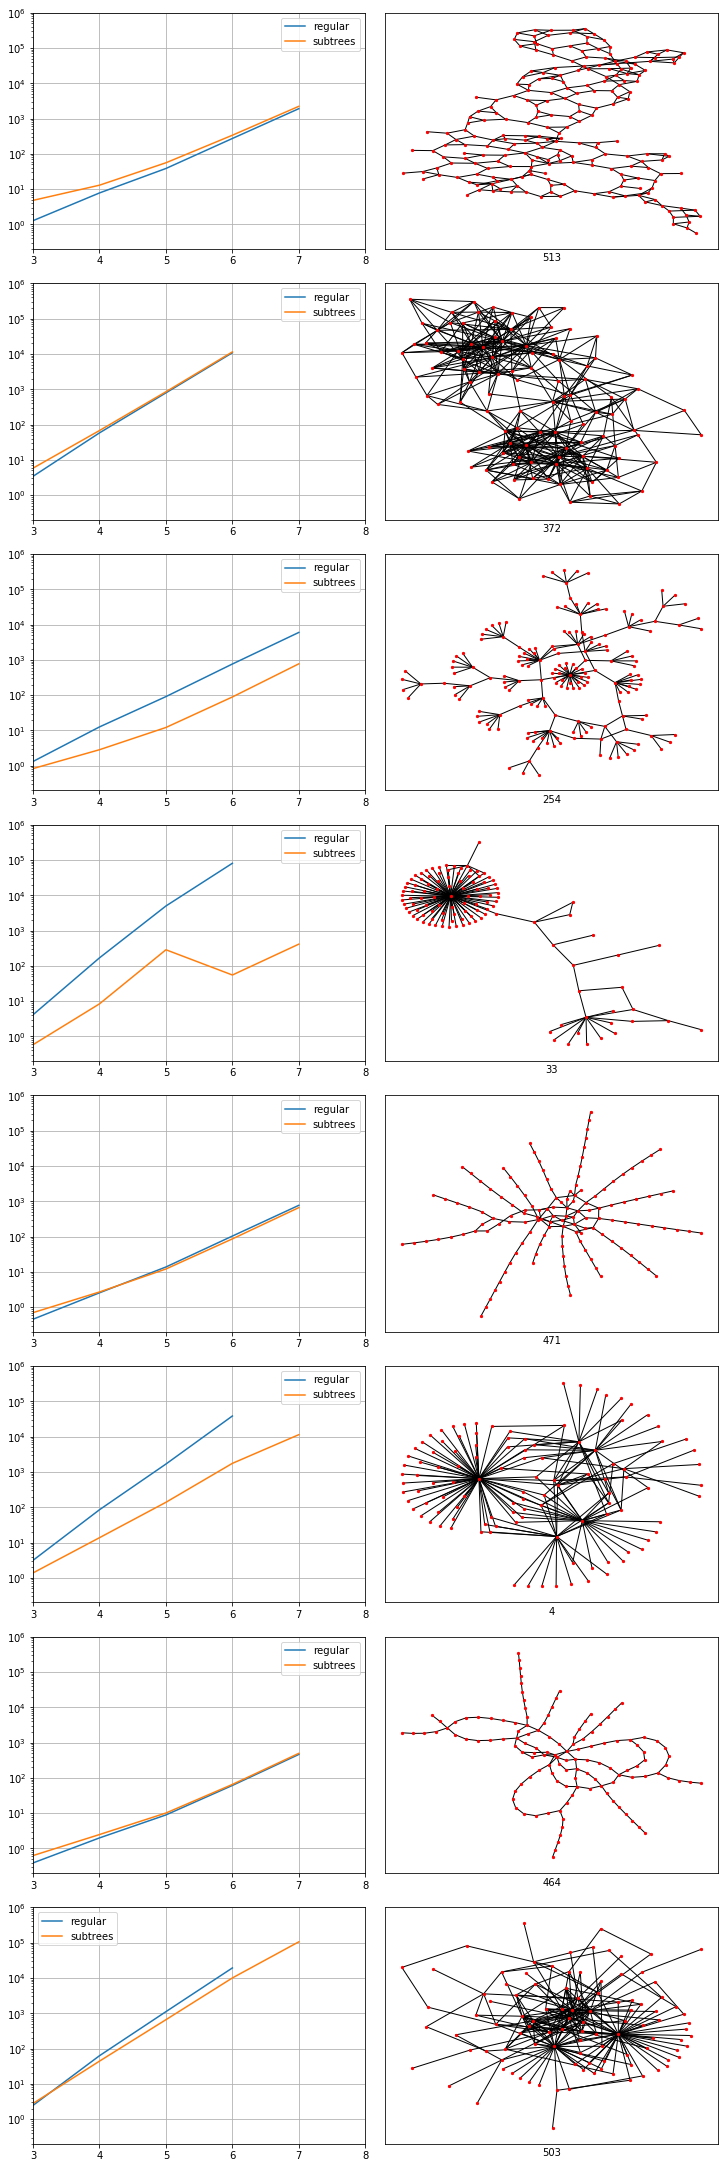

In [534]:
from matplotlib.ticker import MaxNLocator

sample = indices_smallSelection
sampleSize = len(sample)

fig1, f1_axes = plt.subplots(ncols=2, nrows=sampleSize, constrained_layout=True)  # Create a figure containing a single axes.

for networkKey, networkIndex in enumerate(sample):
    ax = f1_axes[networkKey,0]
    ax.plot([i for i in range(3,8)], [runtimes[networkIndex][i]['total_fnr'] for i in range(3,8)], label='regular')
    ax.plot([i for i in range(3,8)], [runtimes[networkIndex][i]['total_fns'] for i in range(3,8)], label='subtrees')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_yscale('log')
    ax.set_ylim([0.2, 1000000])
    ax.set_xlim([3, 8])
    ax.grid(True)
    ax.legend()

    edges = data_edgelists.iloc[networkIndex]
    Graph = nx.Graph()
    Graph.add_edges_from(edges)
    pos = nx.drawing.kamada_kawai_layout(Graph, scale=1)
    nodes = nx.draw_networkx_nodes(Graph, pos=pos, node_size = 5, ax = f1_axes[networkKey,1])
    edges = nx.draw_networkx_edges(Graph, pos=pos, ax = f1_axes[networkKey,1])
    f1_axes[networkKey,1].set_xticks([])
    f1_axes[networkKey,1].set_yticks([])
    f1_axes[networkKey,1].set_xlabel(str(networkIndex))
    
fig1.set_size_inches(10, 30)


In [21]:
fig1.savefig("runtime_comparison_8sample.pdf", bbox_inches='tight')

### sample queries from network

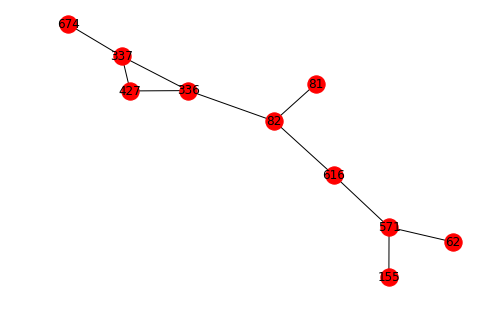

In [547]:
networkIndex = 402
networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)

sampleGraph = sampleSubgraph(networkGraph, 10)
nx.draw(sampleGraph, with_labels=True)

In [548]:
graphToString(sampleGraph)

'[[674,337], [616,82], [616,571], [427,336], [427,337], [155,571], [336,82], [336,337], [81,82], [571,62]]'

### write sampled queries to file

In [505]:
# write text file of sampled query strings
data = []
querySize = 20

for i in range(10):
    sampleGraph = sampleSubgraph(networkGraph, querySize)
    sampleString = graphToString(sampleGraph)
    data.append(str(i) + ' ' + sampleString + '\n')
    
f = open('test_data/sampledgraphs' + str(querySize) + '.txt', 'w')
f.writelines(data)

## debug

In [133]:
q6_18 = '[[0,5], [1,5], [2,5], [3,5], [4,5]]'
q6_19 = '[[0,1], [1,2], [2,5], [3,4], [3,5], [4,5]]'
q6_5 = '[[0,4], [1,4], [2,5], [3,5], [4,5]]'
q6_38 = '[[0,5], [1,2], [1,5], [2,5], [3,4], [3,5], [4,5]]'
q2 = '[[0,1]]'

queryString = q2
networkIndex = 33

networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)
networkString = graphToString(networkGraph)

queryGraph = parseStringToGraph(queryString)

start_time_fns = time.time()
out_fns = fns_wc.findSubgraphInstances(queryString, networkString)
delta_fns = time.time() - start_time_fns

start_time_fnr = time.time()
out_fnr = fnr_wc.findSubgraphInstances(queryGraph, networkGraph)
delta_fnr = time.time() - start_time_fnr
 
print('regular:', out_fnr, 'runtime:', delta_fnr)
print('subtrees:', out_fns, 'runtime:', delta_fns)

regular: 123 runtime: 0.057308197021484375
subtrees: 123 runtime: 0.25194287300109863


# useful functions

In [5]:
def sampleSubgraph(networkGraph, sampleSize):
    node = np.random.choice(list(networkGraph.nodes()), 1)[0]
    selection = [node]
    neighborhood = set(networkGraph[node])
    size = 1
    
    while size < sampleSize:
        newNode = np.random.choice(list(neighborhood), 1)[0]
        selection.append(newNode)
        neighborhood = neighborhood.union(set(networkGraph[newNode])).difference(set(selection))
        size = size +1
        
    return networkGraph.subgraph(selection)

def plotNetwork(index, nodeSize=50, withLabels=False, figSize=10):
    edges = data_edgelists.iloc[index]

    Graph = nx.Graph()
    Graph.add_edges_from(edges)
    pos = nx.drawing.kamada_kawai_layout(Graph, scale=1)
    fig, ax = plt.subplots()
    fig.set_size_inches(figSize, figSize)
    nodes = nx.draw_networkx_nodes(Graph, pos=pos, node_size = nodeSize, ax = ax)
    edges = nx.draw_networkx_edges(Graph, pos=pos, ax = ax)
    
    if (withLabels):
        labels = nx.draw_networkx_labels(Graph, pos=pos)

    plt.show()

def parseStringToGraph(s):
    l = []
    
    if(s[len(s)-1] == ' '):
        s = s[:-1]
    
    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]
        
        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]
            
            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))
    
    H = nx.Graph()
    H.add_edges_from(l)
    
    return H

def graphToString(G):
    edges = list(G.edges())
    string = '['
    
    for edge in edges:
        to_add = '[' + str(edge[0]) + ',' + str(edge[1]) + '], '
        string += to_add
        
    string = string[:len(string)-2]
    string += ']'
    
    return string

# takes a graph G and "grows" a 1-shell from it until it reaches size size
def growOneShell(G, size, seed):
    K = nx.Graph()
    rnd.seed(seed)
    
    if (size < len(G)):
        print('size too small')
        return
    
    n = len(G)
    m = size - n
    
    weighedNodeList = []
    
    for n in G.nodes():
        mult = [n]*len(G[n])
        weighedNodeList = weighedNodeList + mult
    
    for newNode in range(n, size):
        adjacentNode = rnd.sample(weighedNodeList, 1)
        G.add_edge(newNode, adjacentNode[0])
        
        for n in G.nodes():
            mult = [n]*len(G[n])
            weighedNodeList = weighedNodeList + mult
        
    K.add_edges_from(G.edges())
    return K


def write_speed_results(outFile, delta_fnr, delta_fns, stringQuery, graphName):
    f = open(outFile, 'r')
    old_data = f.readlines()
    
    of = open(outFile, 'w')
    str_subtrees_time = str(delta_fns)
    str_regular_time = str(delta_fnr)
    
    data = old_data + ['query graph: ', stringQuery, ', network: ', graphName, ', subtrees: ', str_subtrees_time, ', regular: ', str_regular_time]

    of.writelines(data)
    
    
def edgeList_to_string(file):
    f = open(file, 'r')
    data = f.readlines()
    string = '['
    
    for index, line in enumerate(data):
        split = line.split()
        
#         print(split[0], split[1])
        
        to_add = '[' + split[0] + ',' + split[1] + '], '
        string += to_add
        
    string = string[:len(string)-2]
    string += ']'
    
    return string

# adds a label column to an edgelist file
def add_label(file):
    f = open(file, 'r')
    
    data = f.readlines()
    
    for index, line in enumerate(data):
        
        split = line.split()
        print(index, data[index], split)
        
        if (len(split) == 1):
            temp = data[index].rstrip() + ' ' + data[index]
            data[index] = temp
            
    f = open(file, 'w')
    f.writelines(data)
    